# Functional Connectivity Matrix & Feature Matrix Construction

Picks up where `01_atlas_resampling_and_roi_extraction.ipynb` leaves off: takes each
subject's ROI time series and computes a functional connectivity matrix (Pearson
correlation between every pair of brain regions), then flattens the upper triangle
into one feature vector per subject to build the final dataset used for classification.

A plain-script equivalent lives at `src/02_build_feature_matrix.py`.

In [1]:
import sys, os
sys.path.append("..")  # repo root, so config.py is importable from notebooks/

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from config import SUBJECTS, OUTPUT_DIR, FEATURE_MATRIX_PATH

print("Number of subjects:", len(SUBJECTS))


Number of subjects: 55


## Functional Connectivity Matrix Computation

After extracting ROI time series for each subject, the next step is to compute the
functional connectivity matrix between brain regions. Functional connectivity measures
the statistical relationship between the BOLD signals of different regions over time.

### Objective

The goal is to determine how strongly different brain regions are functionally
connected by computing the Pearson correlation coefficient between their time series.

### Pearson Correlation Coefficient

$$
r = \frac{ \sum_{i=1}^{n} (x_i - \bar{x})(y_i - \bar{y}) }{ \sqrt{\sum_{i=1}^{n} (x_i - \bar{x})^2} \sqrt{\sum_{i=1}^{n} (y_i - \bar{y})^2} }
$$

Where:

* $x_i, y_i$ are the signal values at time point $i$
* $\bar{x}, \bar{y}$ are the mean values of the signals
* $n$ is the number of time points

### Interpretation

* $r \approx 1$ &rarr; strong positive correlation (regions activate together)
* $r \approx 0$ &rarr; no relationship
* $r \approx -1$ &rarr; strong negative correlation (opposite behavior)

### Connectivity Matrix

For each subject:

* Input: ROI time series of shape $(T, R)$
* Output: Connectivity matrix of shape $(R, R)$

Where $T$ = number of time points, $R$ = number of brain regions. Each element
$(i, j)$ represents the correlation between region $i$ and region $j$.

### Properties of the Matrix

* Symmetric: $corr(i,j) = corr(j,i)$
* Diagonal values = 1
* Values range between $[-1, 1]$

### Importance for Machine Learning

The connectivity matrix captures the relationships between brain regions and serves
as the basis for feature extraction. These features will be used to:

* differentiate Parkinson's patients from healthy controls
* train classification models
* identify abnormal connectivity patterns

In [2]:
for sub in SUBJECTS:
    subject_folder = os.path.join(OUTPUT_DIR, sub)

    roi_csv = os.path.join(subject_folder, f"{sub}_roi_time_series.csv")
    output_csv = os.path.join(subject_folder, f"{sub}_connectivity.csv")

    if not os.path.exists(roi_csv):
        print(f"Missing ROI CSV for {sub}")
        continue

    df = pd.read_csv(roi_csv)
    roi_data = df.values   # shape: (200, 116)

    # Compute Pearson correlation between regions
    connectivity_matrix = np.corrcoef(roi_data, rowvar=False)  # rowvar=False is necessary because:
                                                                # - rows = time points
                                                                # - columns = brain regions
                                                                # We want correlation between columns, not rows

    # Save as DataFrame with ROI names
    conn_df = pd.DataFrame(
        connectivity_matrix,
        index=df.columns,
        columns=df.columns
    )

    conn_df.to_csv(output_csv, index=True)

    print(f"{sub}: saved {conn_df.shape} to {output_csv}")


sub-MJF001: saved (116, 116) to C:/Users/XPRISTO/Desktop/PD_PROJECT\derivatives\sub-MJF001\sub-MJF001_connectivity.csv
sub-MJF002: saved (116, 116) to C:/Users/XPRISTO/Desktop/PD_PROJECT\derivatives\sub-MJF002\sub-MJF002_connectivity.csv
sub-MJF003: saved (116, 116) to C:/Users/XPRISTO/Desktop/PD_PROJECT\derivatives\sub-MJF003\sub-MJF003_connectivity.csv
sub-MJF006: saved (116, 116) to C:/Users/XPRISTO/Desktop/PD_PROJECT\derivatives\sub-MJF006\sub-MJF006_connectivity.csv
sub-MJF007: saved (116, 116) to C:/Users/XPRISTO/Desktop/PD_PROJECT\derivatives\sub-MJF007\sub-MJF007_connectivity.csv
sub-MJF008: saved (116, 116) to C:/Users/XPRISTO/Desktop/PD_PROJECT\derivatives\sub-MJF008\sub-MJF008_connectivity.csv
sub-MJF009: saved (116, 116) to C:/Users/XPRISTO/Desktop/PD_PROJECT\derivatives\sub-MJF009\sub-MJF009_connectivity.csv
sub-MJF010: saved (116, 116) to C:/Users/XPRISTO/Desktop/PD_PROJECT\derivatives\sub-MJF010\sub-MJF010_connectivity.csv
sub-MJF011: saved (116, 116) to C:/Users/XPRISTO

## Visualize one subject's connectivity matrix

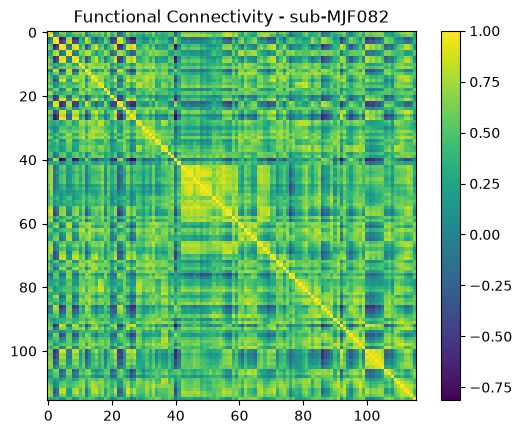

In [3]:
example_subject = SUBJECTS[-1]
example_conn = pd.read_csv(os.path.join(OUTPUT_DIR, example_subject, f"{example_subject}_connectivity.csv"), index_col=0)

plt.imshow(example_conn.values)
plt.colorbar()
plt.title(f"Functional Connectivity - {example_subject}")
plt.show()


## Feature Extraction and Dataset Preparation

After computing the functional connectivity matrix for each subject, the next step is
to extract numerical features that can be used as input for machine learning models.

Since the connectivity matrix is symmetric, it contains redundant information.
Therefore, only the upper triangular part of the matrix, excluding the diagonal, is
retained.

### Objective

The goal of this step is to transform each subject's connectivity matrix into a
one-dimensional feature vector. This produces a dataset where:

* each row corresponds to one subject
* each column corresponds to one functional connection between two brain regions

### Principle

For a connectivity matrix of size $(R, R)$, only the upper triangle without the
diagonal is extracted. The number of resulting features is:

$$
\frac{R(R-1)}{2}
$$

For $R = 116$:

$$
\frac{116 \times 115}{2} = 6670
$$

Thus, each subject is represented by a feature vector of length 6670.

### Output

The final feature matrix has shape $(N, F)$, where $N$ = number of subjects and
$F$ = number of extracted features. For 55 subjects: $(55, 6670)$.

This matrix will be used as input for classification models.

In [4]:
X = []
subject_list = []

for sub in SUBJECTS:
    conn_path = os.path.join(OUTPUT_DIR, sub, f"{sub}_connectivity.csv")

    if not os.path.exists(conn_path):
        print(f"Missing connectivity file for {sub}")
        continue

    # Load connectivity matrix
    conn_df = pd.read_csv(conn_path, index_col=0)
    conn_matrix = conn_df.values

    # Extract upper triangle without diagonal
    features = conn_matrix[np.triu_indices_from(conn_matrix, k=1)]

    X.append(features)
    subject_list.append(sub)

# Convert to numpy array
X = np.array(X)

# Save the feature matrix
X_df = pd.DataFrame(X, index=subject_list)
X_df.index.name = "Subject"
X_df.to_csv(FEATURE_MATRIX_PATH, index=True)

print("Feature matrix saved to:", FEATURE_MATRIX_PATH)
print("Feature matrix shape:", X.shape)
print("Number of subjects loaded:", len(subject_list))
print("Number of features per subject:", X.shape[1])


Feature matrix saved to: C:/Users/XPRISTO/Desktop/PD_PROJECT\derivatives\feature_matrix.csv
Feature matrix shape: (55, 6670)
Number of subjects loaded: 55
Number of features per subject: 6670


In [5]:
# Inspect one subject
print("First subject:", subject_list[0])
print("First 10 features:", X[0][:10])


First subject: sub-MJF001
First 10 features: [0.77516028 0.76940543 0.80341236 0.32156366 0.28907691 0.73263135
 0.66536329 0.49197056 0.24503961 0.70244203]
